In [35]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator

folder_path = "."

def read_spectrum(file_path):
    df = pd.read_csv(file_path, skiprows=1)
    df = df.rename(columns={"WL/nm": "wavelength_nm", "Abs": "absorbance"})
    return df[["wavelength_nm", "absorbance"]].dropna().reset_index(drop=True)

def find_local_maxima(df, n_peaks=1, min_distance_nm=20, peak_range=None):
    peaks = get_local_maxima(df, peak_range=peak_range)
    selected = []
    for peak_x, peak_y in peaks:
        if all(abs(peak_x - selected_x) >= min_distance_nm for selected_x, _ in selected):
            selected.append((peak_x, peak_y))
        if len(selected) >= n_peaks:
            break
    return selected


In [36]:
# -*- coding: utf-8 -*-

import math
import linecache
#import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
from itertools import cycle
from scipy.optimize import fsolve, root_scalar

ModuleNotFoundError: No module named 'scipy'

<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_36458/3069247734.py:80: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('wavelength $\lambda$,nm',size=10)


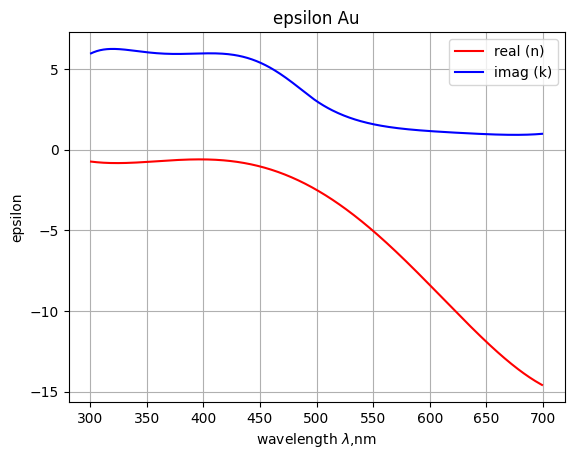

In [37]:
wl_START = 300.
wl_END = 700.

def epsilon_apprx(wl, material):
    if (material=='Ag')or(material=='ag'):
        eps_re=-2.6865E-07*math.pow(wl,3.) + 3.8087E-04*math.pow(wl,2.) - 2.2651E-01*wl + 4.2683E+01
        eps_im=-4.7809E-10*math.pow(wl,4.) + 1.1384E-06*math.pow(wl,3.) - 1.0042E-03*wl*wl + 3.9173E-01*wl - 5.6635E+01
        if(wl<480):
            eps_im=2.1779E-12*math.pow(wl,6.) - 5.4720E-09*math.pow(wl,5.) + 5.7085E-06*math.pow(wl,4.) - 3.1651E-03*math.pow(wl,3.) + 9.8372E-01*wl*wl - 1.6250E+02*wl + 1.1147E+04
    elif (material=='Au')or(material=='au'):
        eps_re=2.3662E-09*math.pow(wl,4.) - 4.5916E-06*math.pow(wl,3.) + 3.1138E-03*math.pow(wl,2.) - 8.9358E-01*wl + 9.1911E+01
        eps_im=5.04357E-09*math.pow(wl,4.) - 1.26287E-05*math.pow(wl,3.) + 1.18720E-02*wl*wl - 4.96993E+00*wl + 7.83346E+02
        if(wl<490):
            eps_im=2.01122E-10*math.pow(wl,5.) - 4.08978E-07*math.pow(wl,4.) + 3.28958E-04*math.pow(wl,3.) - 1.30931E-01*wl*wl + 2.58011E+01*wl - 2.00847E+03
#        eps_im= -1.8060E-11*math.pow(wl,5.) + 4.4837E-08*math.pow(wl,4.) - 4.3176E-05*math.pow(wl,3.) + 2.0100E-02*math.pow(wl,2.) - 4.5305E+00*wl + 4.0275E+02
    elif (material=='water')or(material=='w'):
        n_re = 1.32334 + 3479./wl/wl - 5.111e7/math.pow(wl,4.) 
        eps_re= n_re*n_re
        eps_im= 0.
    elif (material=='vacuum')or(material=='vac'):
        eps_re= 1.
        eps_im= 0.

    epsilon = eps_re + eps_im*1.j
    return epsilon

wl_range = np.arange(wl_START,wl_END)

eps_0_au = []
eps_1_au = []
eps_2_au = []
nn_2_au = []
kk_2_au = []
eps_re_au = []
eps_im_au = []

frac = 1.0

for i in range(len(wl_range)):
    eps_0_au.append(epsilon_apprx(wl_range[i],'w'))
    eps_1_au.append(epsilon_apprx(wl_range[i],'Au'))
    eps_delta = eps_1_au[i]-eps_0_au[i]
    f1 = (1.+2.*frac)/3.
    f2 = (1.-frac)/3.
    eps_tmp = (eps_0_au[i] + f1*eps_delta)/(eps_0_au[i] + f2*eps_delta)
    eps_2_au.append(eps_0_au[i]*eps_tmp)
    eps_re = np.real(eps_2_au[i])
    eps_im = np.imag(eps_2_au[i])
    eps_re_au.append(eps_re)
    eps_im_au.append(eps_im)
    eps_abs = np.power((eps_re**2 + eps_im**2),0.5)
    nn_2_au.append( np.power(((eps_abs+eps_re)/2),0.5) )
    kk_2_au.append( np.power(((eps_abs-eps_re)/2),0.5) )

eps_0_ag = []
eps_1_ag = []
eps_2_ag = []
nn_2_ag = []
kk_2_ag = []
eps_re_ag = []
eps_im_ag = []

for i in range(len(wl_range)):
    eps_0_ag.append(epsilon_apprx(wl_range[i],'w'))
    eps_1_ag.append(epsilon_apprx(wl_range[i],'Ag'))
    eps_delta = eps_1_ag[i]-eps_0_ag[i]
    f1 = (1.+2.*frac)/3.
    f2 = (1.-frac)/3.
    eps_tmp = (eps_0_ag[i] + f1*eps_delta)/(eps_0_ag[i] + f2*eps_delta)
    eps_2_ag.append(eps_0_ag[i]*eps_tmp)
    eps_re = np.real(eps_2_ag[i])
    eps_im = np.imag(eps_2_ag[i])
    eps_re_ag.append(eps_re)
    eps_im_ag.append(eps_im)
    eps_abs = np.power((eps_re**2 + eps_im**2),0.5)
    nn_2_ag.append( np.power(((eps_abs+eps_re)/2),0.5) )
    kk_2_ag.append( np.power(((eps_abs-eps_re)/2),0.5) )
    
plt.figure()
plt.xlabel('wavelength $\lambda$,nm',size=10)
plt.ylabel('epsilon',size=10)
plt.plot(wl_range[1:],eps_re_au[1:],color='red',label='real (n)')
plt.plot(wl_range[1:],eps_im_au[1:],color='blue',label='imag (k)')

plt.legend(loc='best')
plt.title('epsilon Au')
plt.grid()
#plt.xlim(-1.0,3.0)
#plt.ylim(0.,None)
#plt.savefig('epsilons.png')
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_36458/737779576.py:2: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('wavelength $\lambda$,nm',size=10)


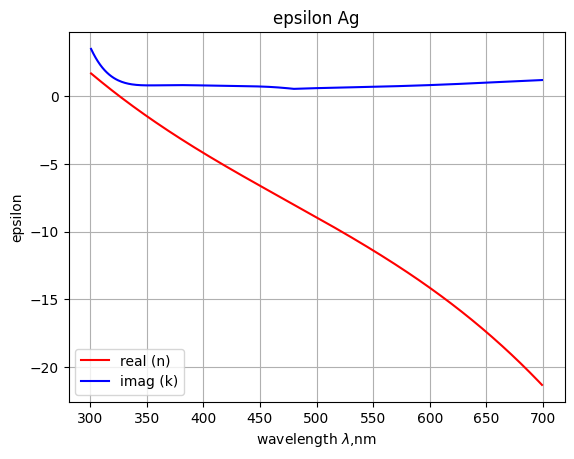

In [38]:
plt.figure()
plt.xlabel('wavelength $\lambda$,nm',size=10)
plt.ylabel('epsilon',size=10)
plt.plot(wl_range[1:],eps_re_ag[1:],color='red',label='real (n)')
plt.plot(wl_range[1:],eps_im_ag[1:],color='blue',label='imag (k)')

plt.legend(loc='best')
plt.title('epsilon Ag')
plt.grid()
#plt.xlim(-1.0,3.0)
#plt.ylim(0.,None)
#plt.savefig('epsilons.png')
plt.show()

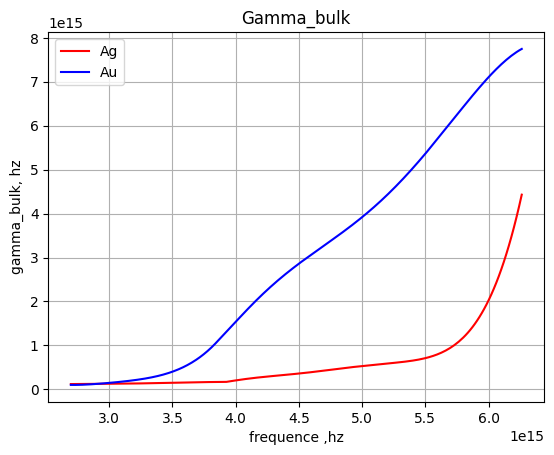

In [39]:
# w = 2*pi*c/lambda
e = 1.6E-19
e_0 = 8.85E-12
m_e = 9.1E-31

m_eff_ag = 0.96 * m_e
m_eff_au = 0.99 * m_e
n_e_ag = 5.85E28 # штуки/m^3
n_e_au = 5.9E28

w_range = 2 * np.pi * 3 * (10 ** 17) / wl_range 
w_p_ag = np.sqrt(n_e_ag * e**2 / (e_0 * m_eff_ag))
w_p_au = np.sqrt(n_e_au * e**2 / (e_0 * m_eff_au))

eps_im_ag_arr = np.array(eps_im_ag)
eps_im_au_arr = np.array(eps_im_au)

# 1. Исправляем имена переменных
# 2. Считаем гамму как функцию от частоты (только для проверки модели)
# Но помните: в расчетах сечения gamma_bulk — это КОНСТАНТА.
gamma_bulk_ag = eps_im_ag_arr * (w_range**3) / (w_p_ag**2)
gamma_bulk_au = eps_im_au_arr * (w_range**3) / (w_p_au**2)

plt.figure()
plt.xlabel('frequence ,hz',size=10)
plt.ylabel('gamma_bulk, hz',size=10)
plt.plot(w_range[1:],gamma_bulk_ag[1:],color='red',label='Ag')
plt.plot(w_range[1:],gamma_bulk_au[1:],color='blue',label='Au')

plt.legend(loc='best')
plt.title('Gamma_bulk')
plt.grid()
#plt.xlim(-1.0,3.0)
#plt.ylim(0.,None)
#plt.savefig('epsilons.png')
plt.show()

In [40]:
# eps_re_au

e_inf_ag = 4.5
e_inf_au = 9.5

C = np.array([0, 20, 40])
n_w = 1.333
b = 0.0014
n_gl = n_w + b*C
e_s = n_gl**2
e_com = -2*e_s
best_au = np.zeros(len(C))
best_ag = np.zeros(len(C))
for j in range(len(C)):
    comp_arr_au = np.zeros(len(eps_re_au))
    comp_arr_ag = np.zeros(len(eps_re_ag))
    for i in range(len(eps_re_au)):
        comp_arr_au[i] = np.abs(eps_re_au[i] - e_com[j])
        comp_arr_ag[i] = np.abs(eps_re_ag[i] - e_com[j])
    best_arg_au = np.argmin(comp_arr_au)
    best_arg_ag = np.argmin(comp_arr_ag)
    best_au[j] = wl_range[best_arg_au]
    best_ag[j] = wl_range[best_arg_ag]
print(best_au, best_ag)

[523. 526. 529.] [388. 391. 394.]


In [41]:
# Получаем список всех CSV-файлов в папке
csv_files = []

for file_name in os.listdir('.'):
    if file_name.endswith(".csv"):
        csv_files.append(file_name)

for file_name in csv_files:
    print(file_name)

AUPVP1.csv
AUCOAG2.csv
AG1_1.csv
AG2SUC1.csv
PT2.csv
PT_1.csv
AG2_1.csv
AG2SUC2.csv
AUSUC1.csv
AUCOAG.csv
AU1.csv
AGCOAG.csv
AUSUC2.csv


In [42]:
def get_local_maxima(df, peak_range=None):
    """
    Возвращает все локальные максимумы, отсортированные по убыванию поглощения.

    Parameters
    ----------
    df : pandas.DataFrame
        Таблица с колонками wavelength_nm и absorbance.
    peak_range : tuple or None
        Диапазон поиска (left, right) в нм.

    Returns
    -------
    list of tuples
        Список пиков [(x1, y1), (x2, y2), ...],
        отсортированный по убыванию y.
    """
    df_work = df.copy()

    if peak_range is not None:
        left, right = peak_range
        df_work = df_work[
            (df_work["wavelength_nm"] >= left) &
            (df_work["wavelength_nm"] <= right)
        ].reset_index(drop=True)

    if len(df_work) < 3:
        return []

    x = df_work["wavelength_nm"].values
    y = df_work["absorbance"].values

    local_peaks = []

    for i in range(1, len(y) - 1):
        if y[i] > y[i - 1] and y[i] > y[i + 1]:
            local_peaks.append((x[i], y[i]))

    local_peaks = sorted(local_peaks, key=lambda p: p[1], reverse=True)
    return local_peaks

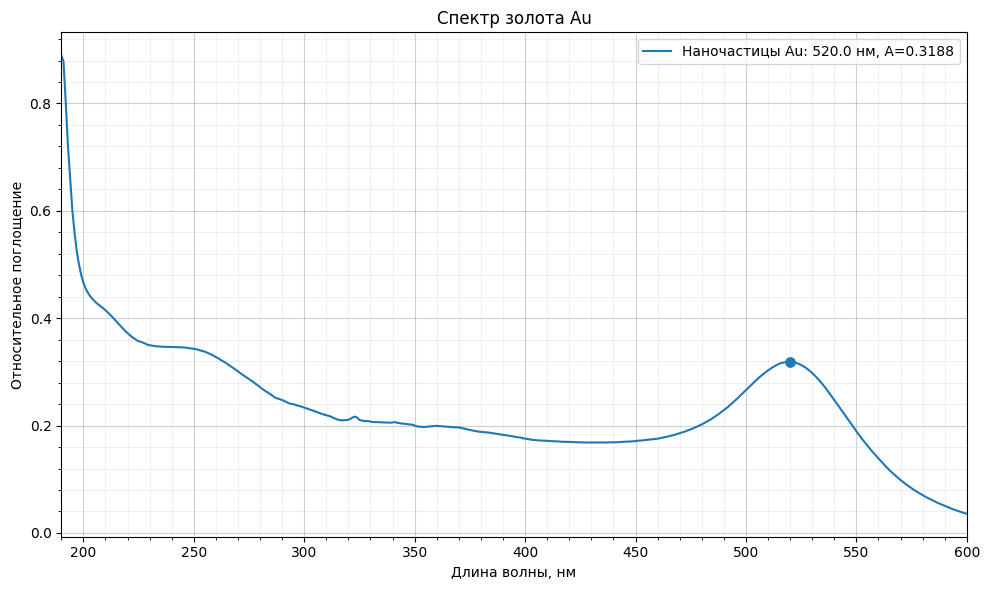

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

file_name = "AU1.csv"
file_path = os.path.join(folder_path, file_name)

df = read_spectrum(file_path)
df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

peaks = find_local_maxima(
    df,
    n_peaks=1,
    min_distance_nm=20,
    peak_range=(450, 580)
)

peak_text = "; ".join([
    f"{peak_x:.1f} нм, A={peak_y:.4f}"
    for peak_x, peak_y in peaks
])

ax.plot(
    df["wavelength_nm"],
    df["absorbance"],
    linewidth=1.5,
    label=f"Наночастицы Au: {peak_text}",
    zorder=2
)

for peak_x, peak_y in peaks:
    ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектр золота Au")

ax.set_xlim(df["wavelength_nm"].min(), 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_1.pdf", bbox_inches="tight")


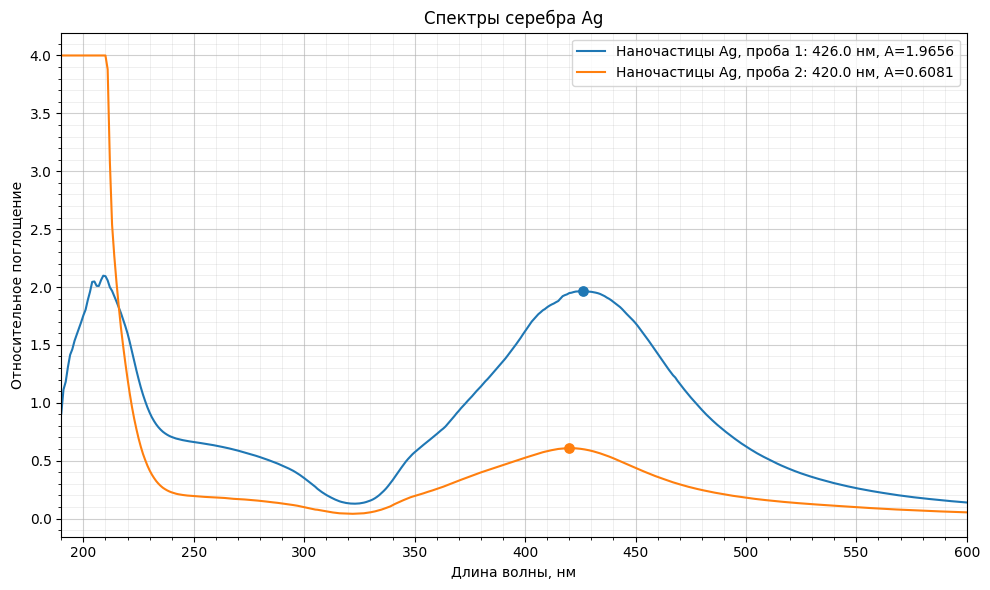

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

silver_files = ["AG1_1.csv", "AG2_1.csv"]

x_min = 600

for file_name in silver_files:
    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df)

    if file_name == "AG1_1.csv":
        sample_label = "Наночастицы Ag, проба 1"

        if len(all_peaks) >= 3:
            peaks = [all_peaks[2]]
        elif len(all_peaks) >= 1:
            peaks = [all_peaks[0]]
        else:
            peaks = []

    else:
        sample_label = "Наночастицы Ag, проба 2"

        if len(all_peaks) >= 1:
            peaks = [all_peaks[0]]
        else:
            peaks = []

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_label}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры серебра Ag")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_2.pdf", bbox_inches="tight")


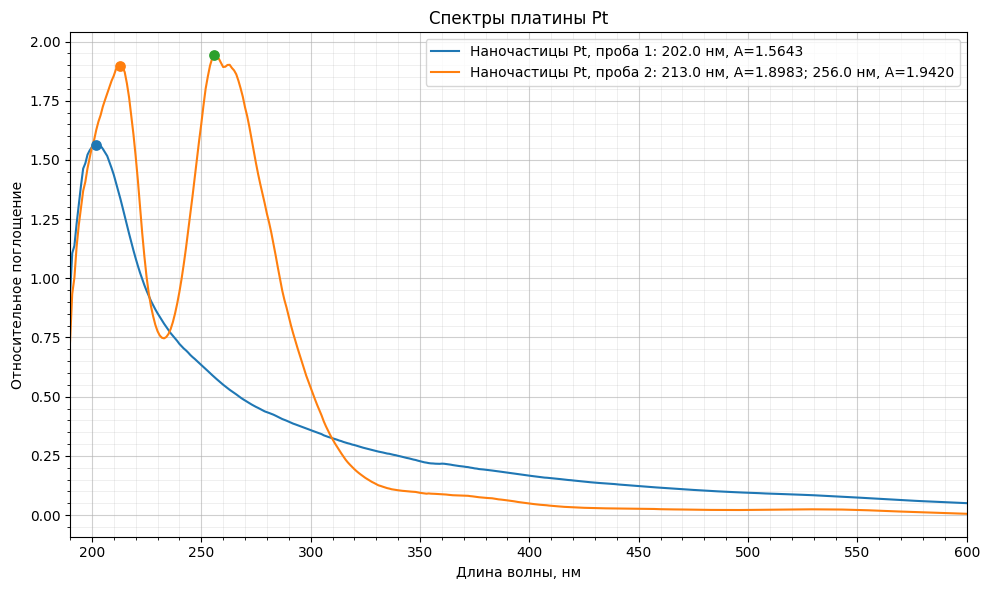

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

platinum_files = ["PT_1.csv", "PT2.csv"]

x_min = 600

for file_name in platinum_files:
    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df)

    if file_name == "PT_1.csv":
        sample_label = "Наночастицы Pt, проба 1"

        # Для Pt1 берем только один максимум
        peaks = all_peaks[:1]

    else:
        sample_label = "Наночастицы Pt, проба 2"

        # Для Pt2 берем 1-й и 3-й пики
        peaks = []

        if len(all_peaks) >= 1:
            peaks.append(all_peaks[0])

        if len(all_peaks) >= 3:
            peaks.append(all_peaks[2])
        elif len(all_peaks) >= 2:
            peaks.append(all_peaks[1])

    peaks = sorted(peaks, key=lambda p: p[0])

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_label}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры платины Pt")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_3.pdf", bbox_inches="tight")


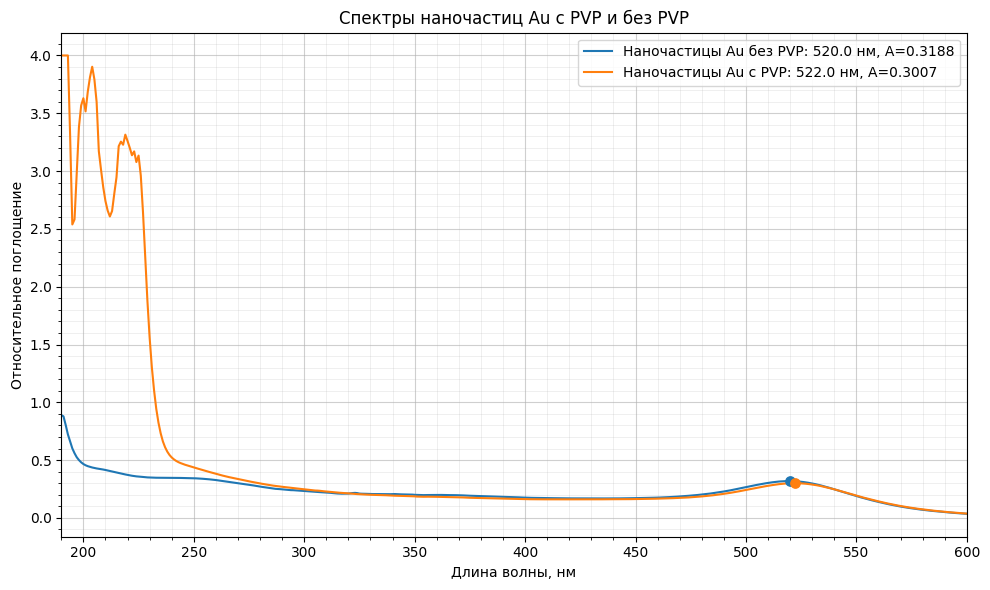

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

au_files = {
    "Наночастицы Au без PVP": {
        "file": "AU1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au с PVP": {
        "file": "AUPVP1.csv",
        "peak_range": (450, 580)
    }
}

x_min = 600

for sample_name, info in au_files.items():
    file_name = info["file"]
    peak_range = info["peak_range"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(
            peak_x,
            peak_y,
            s=45,
            zorder=3
        )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au с PVP и без PVP")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_pvp.pdf", bbox_inches="tight")


In [60]:
e_sol = 10

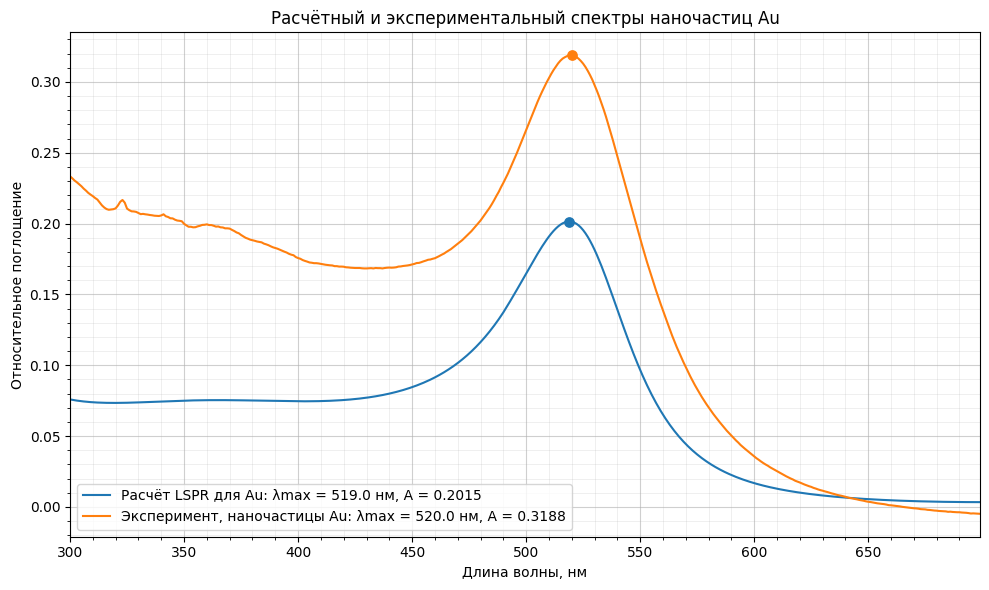

In [73]:
n_glucose_solution = 5

absorption_au = []

for i in range(len(wl_range)):
    e_metal = epsilon_apprx(wl_range[i], "Au")
    e_sol = 1.33

    alpha_im = np.imag(
        (e_metal - e_sol) / (e_metal + 2 * e_sol)
    ) / 8

    absorption_au.append(alpha_im)

absorption_au = np.array(absorption_au)

# Пик расчётных данных
theory_peak_idx = np.argmax(absorption_au)
theory_peak_x = wl_range[theory_peak_idx]
theory_peak_y = absorption_au[theory_peak_idx]


fig, ax = plt.subplots(figsize=(10, 6))

# Расчётный спектр
ax.plot(
    wl_range,
    absorption_au,
    linewidth=1.5,
    label=f"Расчёт LSPR для Au: λmax = {theory_peak_x:.1f} нм, A = {theory_peak_y:.4f}",
    zorder=2
)

ax.scatter(
    theory_peak_x,
    theory_peak_y,
    s=45,
    zorder=3
)

# Экспериментальный спектр AU1
file_name = "AU1.csv"
file_path = os.path.join(folder_path, file_name)

df = read_spectrum(file_path)

df = df[
    (df["wavelength_nm"] >= min(wl_range)) &
    (df["wavelength_nm"] <= max(wl_range))
].reset_index(drop=True)

peaks = find_local_maxima(
    df,
    n_peaks=1,
    min_distance_nm=20,
    peak_range=(450, 580)
)

peak_text = "; ".join([
    f"λmax = {peak_x:.1f} нм, A = {peak_y:.4f}"
    for peak_x, peak_y in peaks
])

ax.plot(
    df["wavelength_nm"],
    df["absorbance"],
    linewidth=1.5,
    label=f"Эксперимент, наночастицы Au: {peak_text}",
    zorder=2
)

for peak_x, peak_y in peaks:
    ax.scatter(
        peak_x,
        peak_y,
        s=45,
        zorder=3
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Расчётный и экспериментальный спектры наночастиц Au")

ax.set_xlim(min(wl_range), max(wl_range))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
plt.show()

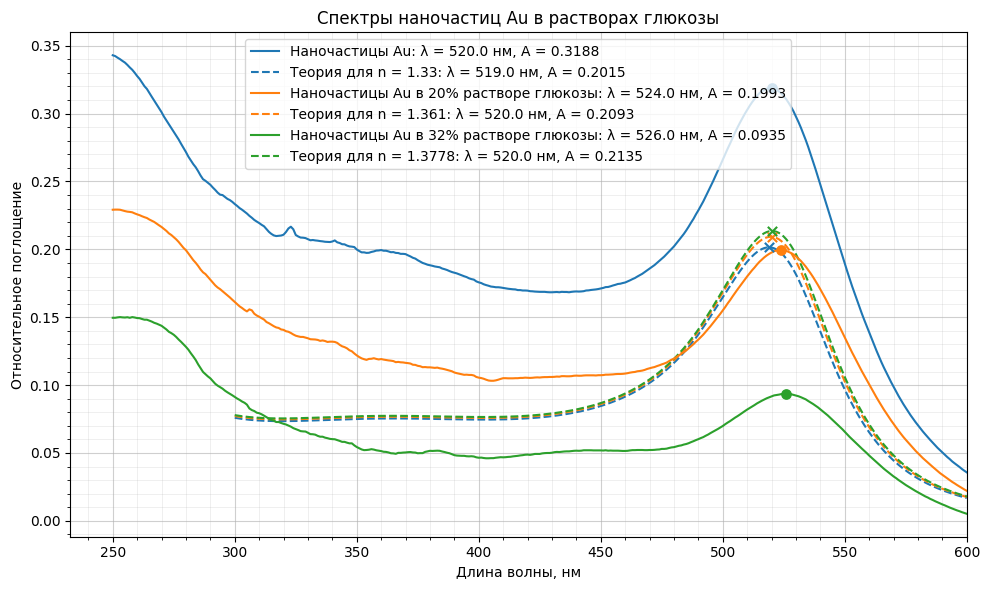

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au = {
    "Наночастицы Au": {
        "file": "AU1.csv",
        "peak_range": (450, 580),
        "n_theory": 1.33
    },
    "Наночастицы Au в 20% растворе глюкозы": {
        "file": "AUSUC1.csv",
        "peak_range": (450, 580),
        "n_theory": 1.361
    },
    "Наночастицы Au в 32% растворе глюкозы": {
        "file": "AUSUC2.csv",
        "peak_range": (450, 580),
        "n_theory": 1.3778
    }
}

wl_theory = np.array(wl_range)

for sample_name, info in samples_au.items():
    file_name = info["file"]
    peak_range = info["peak_range"]
    n_theory = info["n_theory"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"λ = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    # Эксперимент
    exp_line, = ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

    # Теоретический расчет
    absorption_theory = []

    for wl in wl_theory:
        e_metal = epsilon_apprx(wl, "Au")

        # Диэлектрическая проницаемость среды: epsilon = n^2
        e_sol = n_theory

        alpha_im = np.imag(
            (e_metal - e_sol) / (e_metal + 2 * e_sol)
        ) / 8

        absorption_theory.append(alpha_im)

    absorption_theory = np.array(absorption_theory)

    theory_mask = (
        (wl_theory >= 250) &
        (wl_theory <= 600)
    )

    wl_theory_plot = wl_theory[theory_mask]
    absorption_theory_plot = absorption_theory[theory_mask]

    theory_peak_idx = np.argmax(absorption_theory_plot)
    theory_peak_x = wl_theory_plot[theory_peak_idx]
    theory_peak_y = absorption_theory_plot[theory_peak_idx]

    ax.plot(
        wl_theory_plot,
        absorption_theory_plot,
        linewidth=1.5,
        linestyle="--",
        color=exp_line.get_color(),
        label=(
            f"Теория для n = {n_theory}: "
            f"λ = {theory_peak_x:.1f} нм, A = {theory_peak_y:.4f}"
        ),
        zorder=1
    )

    ax.scatter(
        theory_peak_x,
        theory_peak_y,
        s=45,
        marker="x",
        color=exp_line.get_color(),
        zorder=3
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au в растворах глюкозы")

ax.set_xlim(right=600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_au.pdf", bbox_inches="tight")
plt.show()

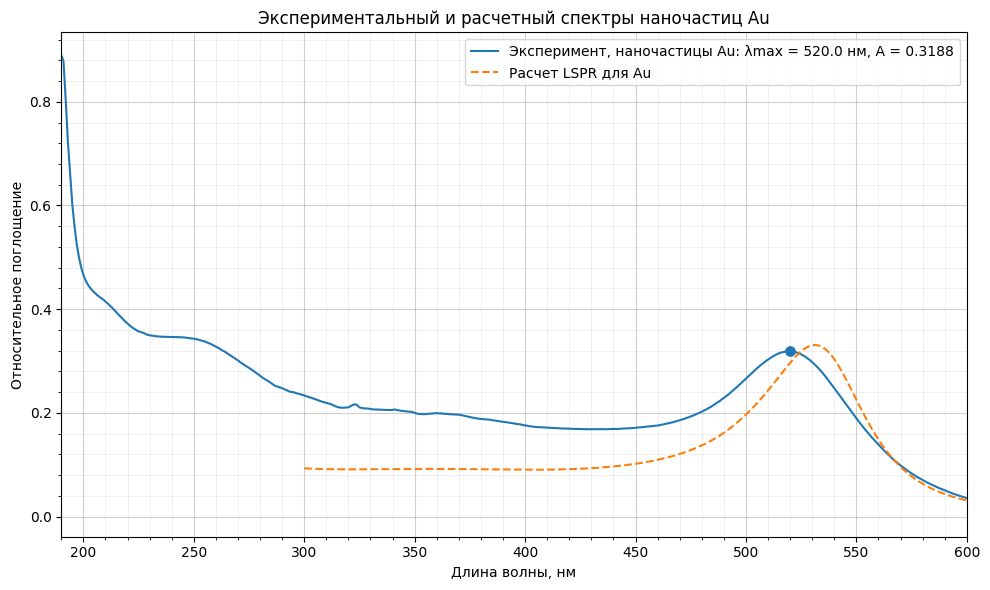

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

file_name = "AU1.csv"
file_path = os.path.join(folder_path, file_name)

df = read_spectrum(file_path)
df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

peaks = find_local_maxima(
    df,
    n_peaks=1,
    min_distance_nm=20,
    peak_range=(450, 580)
)

peak_text = "; ".join([
    f"λmax = {peak_x:.1f} нм, A = {peak_y:.4f}"
    for peak_x, peak_y in peaks
])

# Экспериментальный спектр
ax.plot(
    df["wavelength_nm"],
    df["absorbance"],
    linewidth=1.5,
    label=f"Эксперимент, наночастицы Au: {peak_text}",
    zorder=2
)

for peak_x, peak_y in peaks:
    ax.scatter(
        peak_x,
        peak_y,
        s=45,
        zorder=3
    )

# Теоретический спектр LSPR
ax.plot(
    wl_range,
    absorption_au,
    linewidth=1.5,
    linestyle="--",
    label="Расчет LSPR для Au",
    zorder=2
)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Экспериментальный и расчетный спектры наночастиц Au")

ax.set_xlim(df["wavelength_nm"].min(), 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_1.pdf", bbox_inches="tight")
plt.show()

In [18]:
n_glucose_solution = 1.333 + 0.0014 * 20 # Допустим, концентрация дала такой индекс

absorption_au = []
for i in range(len(wl_range)):
    e_metal = epsilon_apprx(wl_range[i], 'Au')
    # n_re_water = 1.333... (уже есть в вашей функции как 'w')
    e_sol = epsilon_apprx(wl_range[i], 'w') 
    
    # Фактор поляризуемости (LSPR резонанс)
    # Максимум этой величины и есть ваш пик поглощения
    alpha_im = np.imag((e_metal - e_sol) / (e_metal + 2 * e_sol))/13
    absorption_au.append(alpha_im)

# Построение графика
plt.plot(wl_range, absorption_au, label='LSPR Absorption Au')

NameError: name 'wl_range' is not defined

In [20]:
n_glucose_solution = 1.333 + 0.0014 * 32 # Допустим, концентрация дала такой индекс

absorption_au = []
for i in range(len(wl_range)):
    e_metal = epsilon_apprx(wl_range[i], 'Au')
    # n_re_water = 1.333... (уже есть в вашей функции как 'w')
    e_sol = epsilon_apprx(wl_range[i], 'w') 
    
    # Фактор поляризуемости (LSPR резонанс)
    # Максимум этой величины и есть ваш пик поглощения
    alpha_im = np.imag((e_metal - e_sol) / (e_metal + 2 * e_sol))/30
    
    absorption_au.append(alpha_im)

# Построение графика
plt.plot(wl_range, absorption_au, label='LSPR Absorption Au')

NameError: name 'wl_range' is not defined

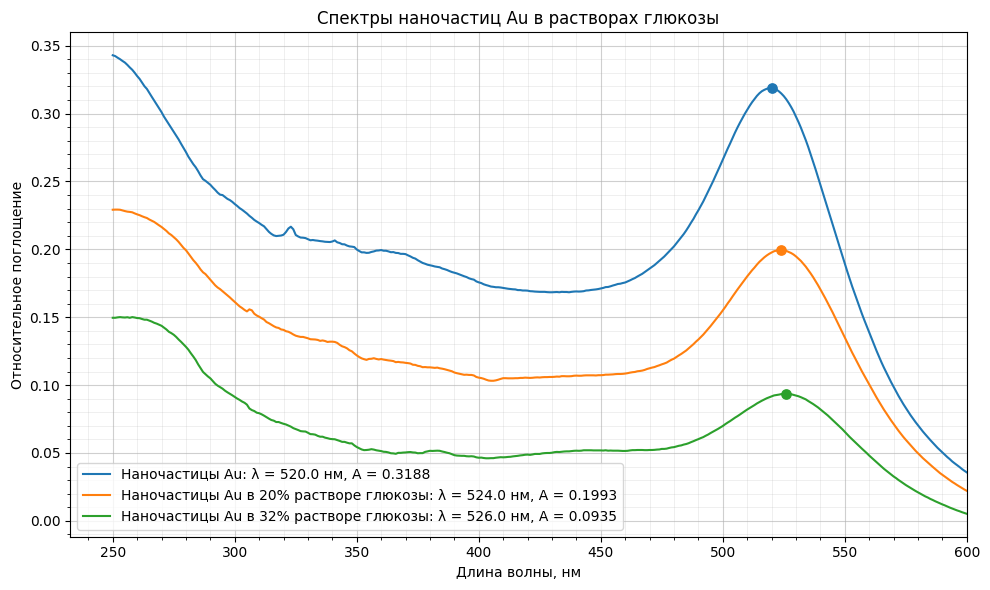

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au = {
    "Наночастицы Au": {
        "file": "AU1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au в 20% растворе глюкозы": {
        "file": "AUSUC1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au в 32% растворе глюкозы": {
        "file": "AUSUC2.csv",
        "peak_range": (450, 580)
    }
}

for sample_name, info in samples_au.items():
    file_name = info["file"]
    peak_range = info["peak_range"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"λ = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au в растворах глюкозы")

ax.set_xlim(right=600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_au.pdf", bbox_inches="tight")


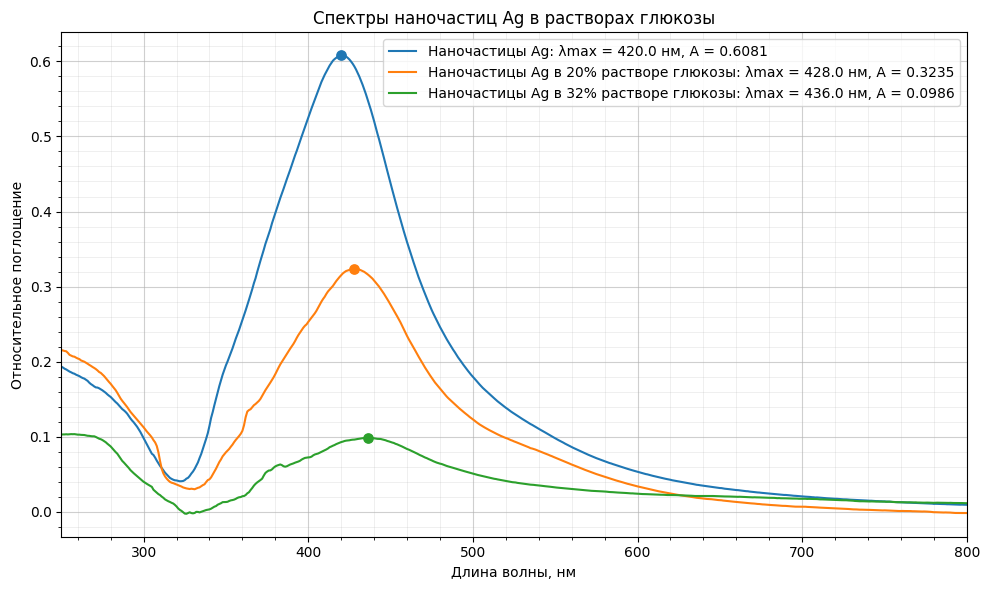

In [15]:
def get_peak_in_range(df, peak_range):
    """
    Находит максимум поглощения в заданном диапазоне длин волн.
    """
    left, right = peak_range

    df_work = df[
        (df["wavelength_nm"] >= left) &
        (df["wavelength_nm"] <= right)
    ].reset_index(drop=True)

    if df_work.empty:
        return []

    peak_idx = df_work["absorbance"].idxmax()

    peak_x = df_work.loc[peak_idx, "wavelength_nm"]
    peak_y = df_work.loc[peak_idx, "absorbance"]

    return [(peak_x, peak_y)]


fig, ax = plt.subplots(figsize=(10, 6))

samples_ag = {
    "Наночастицы Ag": {
        "file": "AG2_1.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    },
    "Наночастицы Ag в 20% растворе глюкозы": {
        "file": "AG2SUC1.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    },
    "Наночастицы Ag в 32% растворе глюкозы": {
        "file": "AG2SUC2.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    }
}

for sample_name, info in samples_ag.items():
    file_name = info["file"]
    peak_range = info["peak_range"]
    y_multiplier = info["y_multiplier"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)

    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 800)
    ].reset_index(drop=True)

    df["absorbance"] = df["absorbance"] * y_multiplier

    peaks = get_peak_in_range(df, peak_range)

    peak_text = "; ".join([
        f"λmax = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(
            peak_x,
            peak_y,
            s=45,
            zorder=3
        )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Ag в растворах глюкозы")

ax.set_xlim(250, 800)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_ag.pdf", bbox_inches="tight")


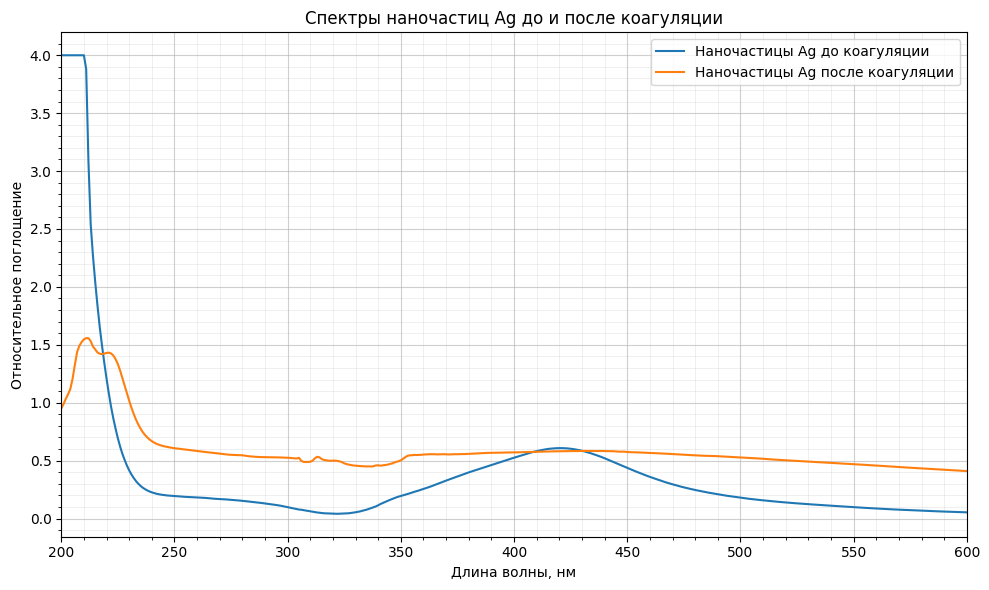

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_ag_coag = {
    "Наночастицы Ag до коагуляции": {
        "file": "AG2_1.csv"
    },
    "Наночастицы Ag после коагуляции": {
        "file": "AGCOAG.csv"
    }
}

for sample_name, info in samples_ag_coag.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Ag до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_ag_caug.pdf", bbox_inches="tight")


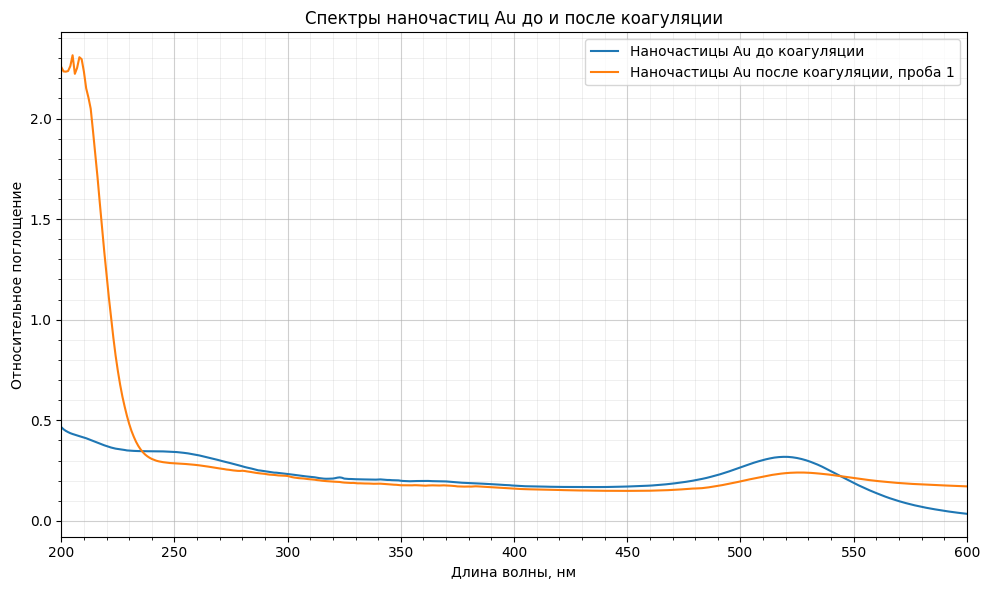

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_1 = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 1": {
        "file": "AUCOAG.csv"
    }
}

for sample_name, info in samples_au_coag_1.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_1.pdf", bbox_inches="tight")


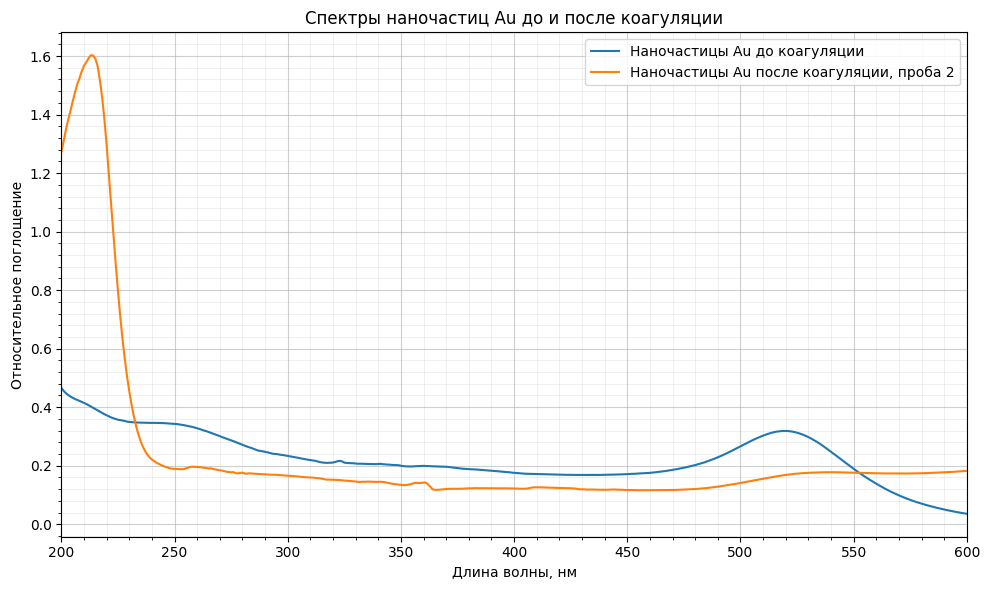

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_2 = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 2": {
        "file": "AUCOAG2.csv"
    }
}

for sample_name, info in samples_au_coag_2.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_2.pdf", bbox_inches="tight")


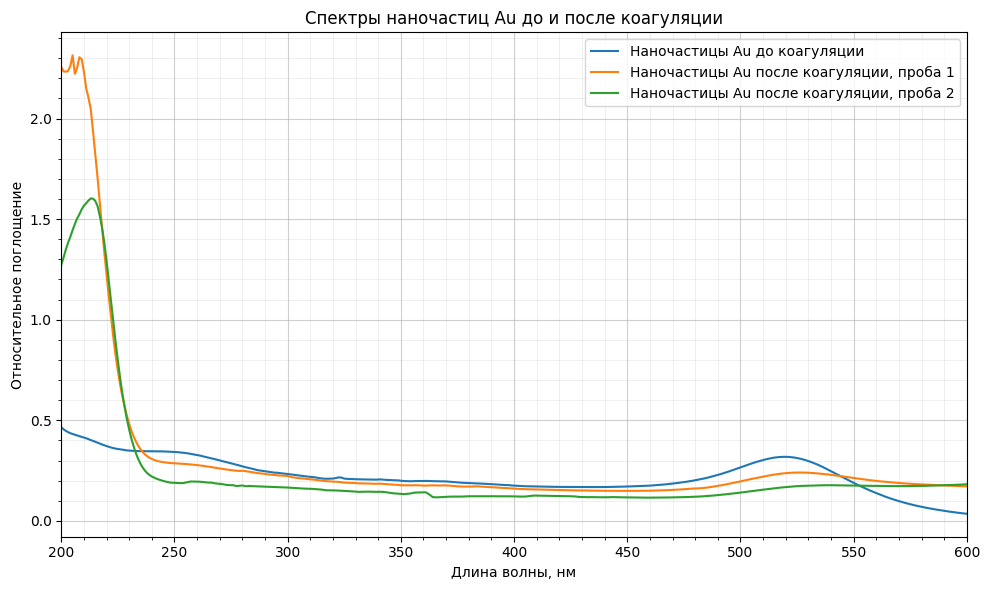

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_all = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 1": {
        "file": "AUCOAG.csv"
    },
    "Наночастицы Au после коагуляции, проба 2": {
        "file": "AUCOAG2.csv"
    }
}

for sample_name, info in samples_au_coag_all.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_all.pdf", bbox_inches="tight")
